In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

METHOD_ORDER = ["multiHIVE_MI", "multiHIVE"]
METHOD_COLOR = {"multiHIVE_MI": "#FF7F0E", "multiHIVE": "#089133"}

def load_data_original(dataset):
    avail_datasets = ["Stephenson", "Brain-ISSAAC", "TEA-3D"]
    if dataset not in avail_datasets:
        raise ValueError(f"Invalid dataset name. Please choose from {avail_datasets}.")
    batch_folder = "/Figures/Batch_metrics/results/multiHIVE/"
    batch_metrics = pd.read_csv(f"{batch_folder}{dataset}_metrics.csv")
    bio_folder = "/Figures/biocon_metrics/Cal_Metrics/clustering_results/multiHIVE/"
    biocon_metrics = pd.read_csv(f"{bio_folder}{dataset}_metrics.csv", index_col=0)
    biocon_metrics.rename(
        columns={
            "normalized_mutual_info": "NMI",
            "adjusted_rand_index": "ARI",
            "fowlkes_mallows": "FMI",
        },
        inplace=True,
    )
    biocon_metrics = biocon_metrics[["NMI", "ARI", "FMI"]].median().to_frame().T
    metrics = pd.concat([biocon_metrics, batch_metrics], axis=1)

    metrics = metrics.melt(var_name="Metric", value_name="Value")
    metrics["Method"] = "multiHIVE"
    return metrics

def load_data_MI(dataset):
    avail_datasets = ["Stephenson", "Brain-ISSAAC", "TEA-3D"]
    if dataset not in avail_datasets:
        raise ValueError(f"Invalid dataset name. Please choose from {avail_datasets}.")
    folder = "../Metrics/Results/"
    batch_metrics = pd.read_csv(f"{folder}{dataset}_batch_metrics.csv")
    biocon_metrics = pd.read_csv(f"{folder}{dataset}_bio_metrics.csv", index_col=0)
    biocon_metrics.rename(
        columns={
            "normalized_mutual_info": "NMI",
            "adjusted_rand_index": "ARI",
            "fowlkes_mallows": "FMI",
        },
        inplace=True,
    )
    biocon_metrics = biocon_metrics[["NMI", "ARI", "FMI"]].median().to_frame().T
    metrics = pd.concat([biocon_metrics, batch_metrics], axis=1)
    metrics = metrics.melt(var_name="Metric", value_name="Value")
    metrics["Method"] = "multiHIVE_MI"
    return metrics

In [23]:
def get_combined_data(dataset):
    data_original = load_data_original(dataset)
    data_ortho = load_data_MI(dataset)
    data_combined = pd.concat([data_original, data_ortho], axis=0)
    data_combined.reset_index(drop=True, inplace=True)
    data_combined["Value"] = data_combined["Value"].fillna(0)
    data_combined["Metric"] = data_combined["Metric"].replace(
        {"Graph Connectivity": "Graph\nConnectivity"}
    )
    return data_combined

def plot_bar_plot(dataset, save_path = None, legend = False):
    sns.barplot(
        data=get_combined_data(dataset),
        x="Metric",
        y="Value",
        hue="Method",
        hue_order=METHOD_ORDER,
        palette=METHOD_COLOR,
    )
    if legend:
        plt.legend(title='Method', bbox_to_anchor=(1.1, 0.6))
    else:
        plt.legend([], [], frameon=False)
    plt.ylabel("Value", fontweight="bold")
    plt.xticks(fontweight="bold")
    plt.yticks(fontweight="bold")
    plt.xlabel("")
    plt.ylim(0, 1)
    sns.despine(top=True, right=True)
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

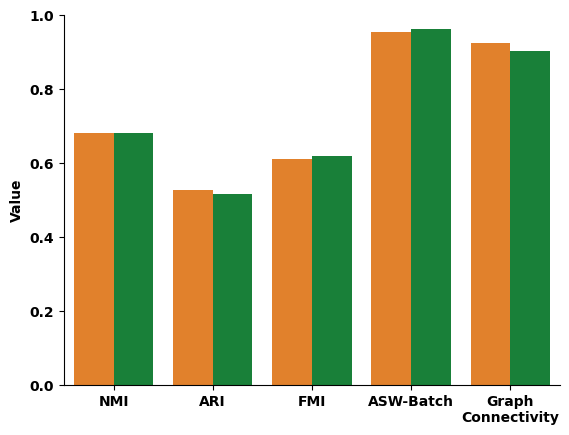

In [24]:
plot_bar_plot("TEA-3D",save_path ="./output/TEA-3D_MI_vs_normal.png")

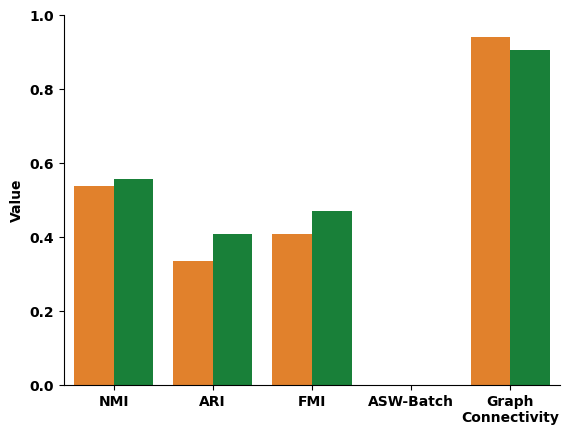

In [25]:
plot_bar_plot("Brain-ISSAAC", save_path="./output/Brain-ISSAAC_MI_vs_normal.png")

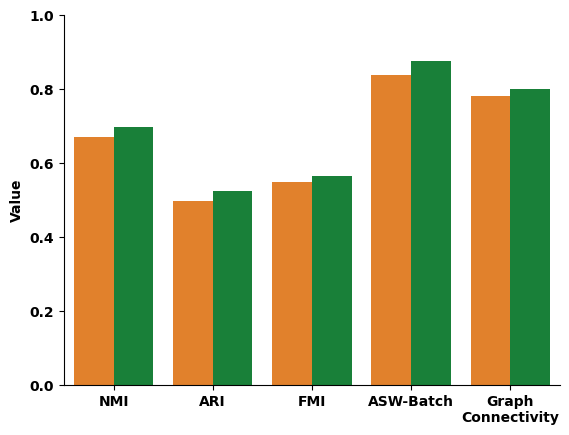

In [26]:
plot_bar_plot("Stephenson", save_path="./output/Stephenson_MI_vs_normal.png")

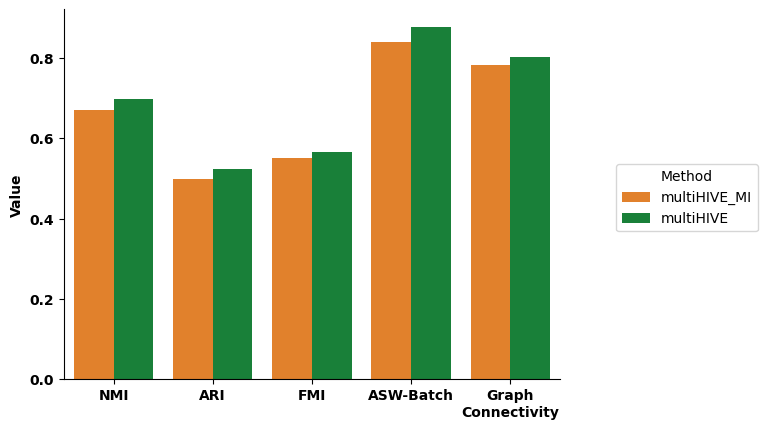

In [ ]:
# plot_bar_plot("Stephenson", save_path="./output/legend.png", legend=True)